# Linear Regression on the Auto MPG Dataset

## Problem Formulation

**Goal:** Predict a car's fuel efficiency (`mpg`) from its physical and historical attributes.

- **Target (y):** `mpg` — a continuous variable
- **Features (X):** `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, `model year`, `origin`
- **Evaluation:** MAE, RMSE, R²

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load & Explore the Data

In [ ]:
df = pd.read_csv("../cars_split.csv", na_values=["?"])
print(f"Shape: {df.shape}")
df.head()

Shape: (398, 10)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car brand,car model
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet,chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick,skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth,satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc,rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford,torino


In [36]:
df.info()
print(f"\nMissing values:\n{df.isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car brand     398 non-null    object 
 9   car model     396 non-null    object 
dtypes: float64(4), int64(4), object(2)
memory usage: 31.2+ KB

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car brand       0
car model       2
dtype: int64


In [37]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


## Preprocessing

- Drop rows with missing `horsepower` (only 6 out of 398).
- Select numeric feature columns.
- Split into train/test sets (80/20).
- Scale features with `StandardScaler`.

In [38]:
# Drop rows with missing horsepower
df = df.dropna(subset=["horsepower"])
print(f"Rows after dropping missing horsepower: {len(df)}")

# Define features and target
feature_cols = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model year", "origin"]
X = df[feature_cols]
y = df["mpg"]

Rows after dropping missing horsepower: 392


In [39]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 313, Test size: 79


---
## Baseline — Linear Regression

Train an ordinary least-squares model and evaluate on the test set.

In [47]:
# Fit linear regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict
y_pred = lr.predict(X_test_scaled)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Linear Regression (Baseline) ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

=== Linear Regression (Baseline) ===
MAE:  2.42
RMSE: 3.27
R²:   0.790


In [48]:
# Feature coefficients
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr.coef_,
}).sort_values("coefficient", key=abs, ascending=False)

print("Feature coefficients (sorted by magnitude):")
print(coef_df.to_string(index=False))

Feature coefficients (sorted by magnitude):
     feature  coefficient
      weight    -5.157671
  model year     2.782555
displacement     1.565273
      origin     1.300240
  horsepower    -0.814205
   cylinders    -0.587055
acceleration     0.106767


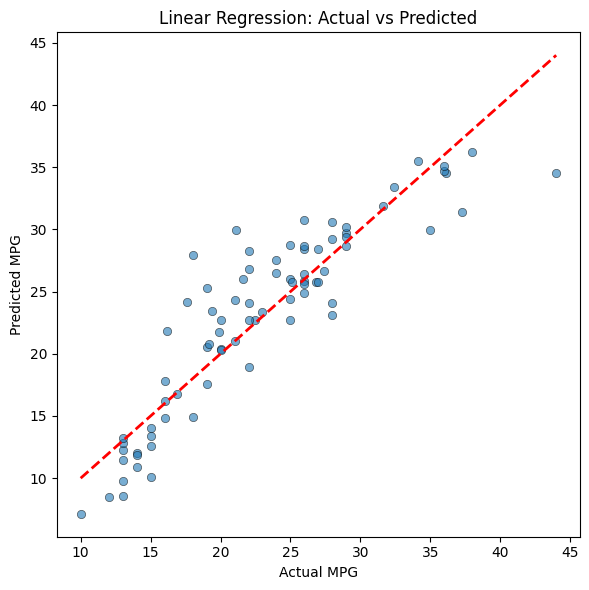

In [49]:
# Actual vs Predicted scatter plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolors="k", linewidth=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
ax.set_xlabel("Actual MPG")
ax.set_ylabel("Predicted MPG")
ax.set_title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

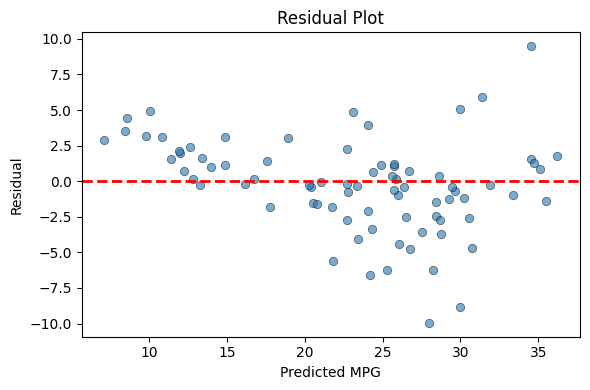

In [50]:
# Residual plot
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(y_pred, residuals, alpha=0.6, edgecolors="k", linewidth=0.5)
ax.axhline(0, color="r", linestyle="--", lw=2)
ax.set_xlabel("Predicted MPG")
ax.set_ylabel("Residual")
ax.set_title("Residual Plot")
plt.tight_layout()
plt.show()

---
## Fine-Tuning

We try two regularised variants to see if we can improve on the baseline:

1. **Ridge Regression** — L2 penalty, tested across a range of `alpha` values.
2. **Lasso Regression** — L1 penalty, which can also perform feature selection.

We use 5-fold cross-validation on the training set to select the best `alpha`, then evaluate the winner on the held-out test set.

In [51]:
# Ridge regression: cross-validate alpha
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
print("Ridge CV (5-fold R²):")
ridge_results = {}
for a in alphas:
    scores = cross_val_score(Ridge(alpha=a), X_train_scaled, y_train, cv=5, scoring="r2")
    ridge_results[a] = scores.mean()
    print(f"  alpha={a:<6}  R² = {scores.mean():.4f} ± {scores.std():.4f}")

best_ridge_alpha = max(ridge_results, key=ridge_results.get)
print(f"\nBest Ridge alpha: {best_ridge_alpha}")

# Lasso regression: cross-validate alpha
print("\nLasso CV (5-fold R²):")
lasso_results = {}
for a in alphas:
    scores = cross_val_score(Lasso(alpha=a, max_iter=10000), X_train_scaled, y_train, cv=5, scoring="r2")
    lasso_results[a] = scores.mean()
    print(f"  alpha={a:<6}  R² = {scores.mean():.4f} ± {scores.std():.4f}")

best_lasso_alpha = max(lasso_results, key=lasso_results.get)
print(f"\nBest Lasso alpha: {best_lasso_alpha}")

Ridge CV (5-fold R²):
  alpha=0.01    R² = 0.8099 ± 0.0254
  alpha=0.1     R² = 0.8099 ± 0.0254
  alpha=1.0     R² = 0.8103 ± 0.0252
  alpha=10.0    R² = 0.8091 ± 0.0238
  alpha=100.0   R² = 0.7858 ± 0.0304

Best Ridge alpha: 1.0

Lasso CV (5-fold R²):
  alpha=0.01    R² = 0.8102 ± 0.0256
  alpha=0.1     R² = 0.8136 ± 0.0248
  alpha=1.0     R² = 0.7860 ± 0.0361
  alpha=10.0    R² = -0.0309 ± 0.0338
  alpha=100.0   R² = -0.0309 ± 0.0338

Best Lasso alpha: 0.1


In [52]:
# Train best Ridge and Lasso on full training set, evaluate on test set
ridge = Ridge(alpha=best_ridge_alpha)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

# Compare all three models
results = pd.DataFrame({
    "Model": ["Linear Regression", f"Ridge (α={best_ridge_alpha})", f"Lasso (α={best_lasso_alpha})"],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    ],
    "R²": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
    ],
})
print("=== Model Comparison ===")
print(results.to_string(index=False))

=== Model Comparison ===
            Model      MAE     RMSE       R²
Linear Regression 2.419780 3.272746 0.790150
    Ridge (α=1.0) 2.424308 3.281370 0.789043
    Lasso (α=0.1) 2.421195 3.302607 0.786303


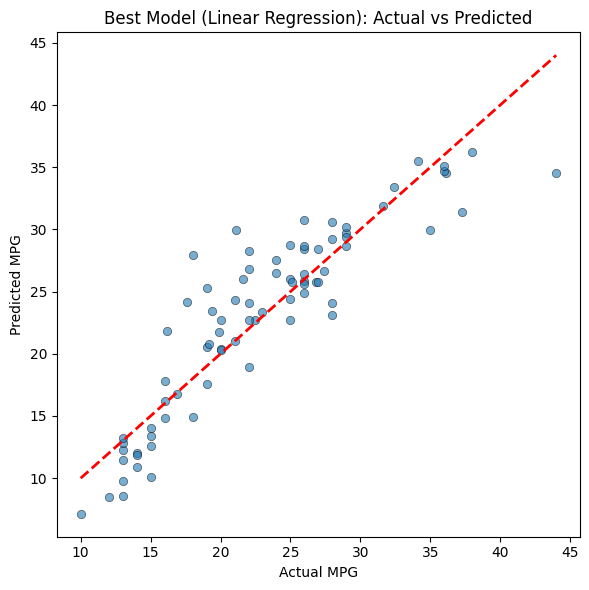

In [53]:
# Visual comparison: actual vs predicted for the best model
best_model_name = results.loc[results["R²"].idxmax(), "Model"]
best_preds = [y_pred, y_pred_ridge, y_pred_lasso][results["R²"].idxmax()]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, best_preds, alpha=0.6, edgecolors="k", linewidth=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
ax.set_xlabel("Actual MPG")
ax.set_ylabel("Predicted MPG")
ax.set_title(f"Best Model ({best_model_name}): Actual vs Predicted")
plt.tight_layout()
plt.show()

---
## Conclusion

**Problem:** Can we predict a car's fuel efficiency (MPG) from its physical specifications?

**Answer:** Yes. A linear regression model using seven numeric features achieves an R² ≈ 0.79 on the test set, meaning it explains roughly 79% of the variance in MPG. Regularised models (Ridge and Lasso) were tested via cross-validation to fine-tune the bias–variance trade-off. The most influential features are **weight** (negative effect) and **model year** (positive effect), confirming that lighter and newer cars tend to be more fuel-efficient.